---
title: "NumPy 基础入门"
description: "本内容面向的读者是没有编程经验的纯编程小白，可以帮助你学习 NumPy 库基础"
date: 2026-08-31

categories:
  - NumPy
  - Code
  - Python
---

此处为提供的一个代码编辑区，可以帮助你简单的使用NumPy：

```{pyodide}
#| caption: "代码编辑区"
# 提供的简单NumPy代码编辑区
```

## 数组基础

导入NumPy时，通常会给他一个别名，如`'np'`，即`import numpy as np`

### 数据类型

#### 整数型数组与浮点型数组

我们前面学习的Python，在建立一个列表时，其会为每一个元素都单独存储其数据类型。为了克服这一个缺点，一个NumPy数组只能容纳一种数据类型，以节约内存。

为方便起见，可将NumPy数组简单的分为整数型数组与浮点型数组

In [5]:
import numpy as np

# 创建整数型数组
arr1 = np.array([1, 2, 3])  # 即元素均为整数
print(arr1)

# 创建浮点型数组
arr2 = np.array([1., 2, 3]) # 即元素中存在浮点数
print(arr2)

# 创建一个列表
a = [1., 2, 3]
print(a)

[1 2 3]
[1. 2. 3.]
[1.0, 2, 3]


注意，使用`print`输出的NumPy数组，元素间是没有逗号的，这有两个好处，一是可以将其与Python列表分开，二是避免逗号与小数点之间的混淆。

#### 同化

- 往整数型数组里插入浮点数，该浮点数会**自动被截断**为整数；
- 往浮点型数组里插入整数，该整数会**自动升级**为浮点数；



In [10]:
import numpy as np

arr1 = np.array([1, 2, 3])
arr1[1] = 2.7
print(arr1)

arr1 = np.array([1., 2, 3])
arr1[1] = 100
print(arr1)

[1 2 3]
[  1. 100.   3.]


#### 共同改变

同化定理告诉我们，整数型数组和浮点型数组之间的界限十分严格，那么如何将这两种数据类型的数组进行相互转化呢？既然某一个人容易被集体所同化，那只要全体共同改变，自然就可以成功。

整数型数组和浮点型数组相互转换，规范的方法是使用`.astype()`方法。

In [12]:
import numpy as np

# 整数型
arr1 = np.array([1, 2, 3])
print(arr1)

# 整数型转换为浮点型
arr2 = arr1.astype(float)
print(arr2)

# 浮点型转换为整数型
arr3 = arr2.astype(int)
print(arr3)

[1 2 3]
[1. 2. 3.]
[1 2 3]


当然，在计算过程中，我们也可以把整数型转换为浮点型数组。

In [15]:
arr = np.array([1, 2, 3])

#  加上一个浮点数
print(arr + 0.0)
print(arr + 1.0)

# 除以任意一个数，包括整数
print(arr / 1)

# 整数型与浮点型数组做加减
arr2 = np.array([1., 2, 3])
print(arr + arr2)
print(arr - arr2)

[1. 2. 3.]
[2. 3. 4.]
[1. 2. 3.]
[2. 4. 6.]
[0. 0. 0.]


整数型数组很好升级，但是浮点型数组一般不会降级。

### 数组维度

#### 一维与二维数组

1. 不同维度的数组之间，从外形上的本质区别是：

    一维数组使用1层中括号表示;\
    二维数组使用2层中括号表示;\
    三维数组使用3层中括号表示。

2. 有些函数需要传入数组的形状参数，不同维度数组的形状参数为：

    一维数组的形状参数形如：`x`或`(x,)`;\
    二维数组的形状参数形如：`(x,y)`;\
    三维数组的形状参数形如：`(x,y,z)`.

3. 现在以同一个序列进行举例:

    当数组有1层中括号，如`[123]`，则其为一维数组，其形状是`3`或`(3,)`;\
    当数组有2层中括号，如`[[123]]`，则其为二维数组，其形状是`(1,3)`;\
    当数组有3层中括号，如`[[[123]]]`，则其为三维数组，其形状是`(1,1,3)`.

此处用`np.ones()`函数来做演示，因为其可以根据形状参数生成数组：

In [17]:
# D-1
arr1 = np.ones(3)
print(arr1)

# D-2
arr2 = np.ones((1, 3))
print(arr2)

# D-3
arr3 = np.ones((1, 1, 3))
print(arr3)

[1. 1. 1.]
[[1. 1. 1.]]
[[[1. 1. 1.]]]


我们可以使用`.shape` 来查看数组的形状:

In [18]:
print(arr1.shape)
print(arr2.shape)
print(arr3.shape)

(3,)
(1, 3)
(1, 1, 3)


我们需要对数组的维度以及尺寸非常敏感，因为深度学习本质上是矩阵相乘，其中我们还会遇到例如concat等操作，都需要我们对尺寸非常的熟悉。

#### 不同维度数组之间的转化

一维数组转二维数组，还是二维数组转一维数组，均要使用的是数组的重塑方法`.reshape()`，该方法需要传入重塑后的形状`（shape）`参数。
这个方法神奇的是，给定了其他维度的数值，剩下一个维度可以填`-1`，让它自己去计算。比如把一个5行6列的矩阵重塑为3行10列的矩阵，当列的参数10告诉它，行的参数直接可以用-1来替代，它会自己去用30除以10来计算。

首先，演示将一维数组升级为二维数组。

In [20]:
arr1 = np.arange(10) # 此处的arange就等同于Python内置的range函数
print(arr1)

arr2 = arr1.reshape((2, -1)) # 将一维数组arr1转换为二维数组
print(arr2)

[0 1 2 3 4 5 6 7 8 9]
[[0 1 2 3 4]
 [5 6 7 8 9]]


相同的，我们可以进行降维，此处我主要介绍如何降低为行向量与列向量。

In [25]:
arr1 = np.arange(10).reshape((2, 5))
print(arr1)

# 将二维数组arr1转换为行向量
arr2 = arr1.reshape(-1)
print(arr2)

# 将二维数组arr1转换为列向量
arr3 = arr1.reshape(-1, 1)
print(arr3)

[[0 1 2 3 4]
 [5 6 7 8 9]]
[0 1 2 3 4 5 6 7 8 9]
[[0]
 [1]
 [2]
 [3]
 [4]
 [5]
 [6]
 [7]
 [8]
 [9]]


## 数组的创建

### 创建指定的数组

当明确知道数组每一个元素的具体数值时，可以使用`np.array()`函数，将Python列表转化为NumPy数组。

In [26]:
# 此部分前面以及讲过了,此处仅仅介绍如何创建一个高维数组

arr1 = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
print(arr1)
print(arr1.shape)

[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]
(2, 2, 3)


### 创建递增数组

递增数组使用`np.arange`进行创建,与Python中自带的`range`函数相似.全称为(array_range)

In [33]:
arr1 = np.arange(10)  # 从0开始,到10之前结束
print(arr1)

arr2 = np.arange(1, 10)  # 从1开始,到10之前结束
print(arr2)

arr3 = np.arange(1, 10, 2)  # 从1开始,到10之前结束,步长为2
print(arr3)

print("*"*100)
# tips: 如果想变成浮点数数组,可以使用:

arr1 = np.arange(10.)
print(arr1)

arr2 = 1.0 * np.arange(1, 10)
print(arr2)

arr3 = 0.0 + np.arange(1, 10, 2)
print(arr3)

arr4 = np.arange(1, 10, 2, dtype=float)  # 从1开始,到10之前结束,步长为2
print(arr4)


[0 1 2 3 4 5 6 7 8 9]
[1 2 3 4 5 6 7 8 9]
[1 3 5 7 9]
****************************************************************************************************
[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[1. 2. 3. 4. 5. 6. 7. 8. 9.]
[1. 3. 5. 7. 9.]
[1. 3. 5. 7. 9.]


###  创建同值数组

In [35]:
# 全0数组
arr1 = np.zeros((3, 4))
print(arr1)

# 全1数组
arr2 = np.ones((3, 4))
print(arr2)

arr3 = 3.14 * np.ones((3, 4))  # 全3.14数组
print(arr3)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]
[[3.14 3.14 3.14 3.14]
 [3.14 3.14 3.14 3.14]
 [3.14 3.14 3.14 3.14]]


示例中隐藏了一个细:两个函数输出的并不是整数型的数组，这可能是为了避免插进去的浮点数被截断，所以将其设定为浮点型数组。

### 创建随机数组

有时需要创建随机数组，那么可以使用`np.random`系列函数：

In [ ]:
arr1 = np.random.random((4, 5))  # 0-1均匀分布的浮点型随机数组
print(arr1)

[[0.56542659 0.72590541 0.40430544 0.7775025  0.8327152 ]
 [0.39271344 0.93031135 0.17020711 0.20867977 0.55185686]
 [0.55878513 0.81159691 0.79947267 0.49254449 0.84692938]
 [0.53963889 0.29382273 0.8183252  0.33987133 0.18780584]]


如果想要将其转化到例如[a, b]范围的均匀分布随机数组，我们可以将其变成`(b-a)*np.random.random((4, 5))+a`

In [40]:
# 随机整数型数组
arr2 = np.random.randint(1, 10, (2, 3))  # 1-10之间的随机整数型数组
print(arr2)  

# 服从正态分布的随机数组
arr3 = np.random.normal(0, 1, (2, 3))
print(arr3)

# 如果是均值为0，标准差为1，我们可以使用np.random.randn()函数来生成一个标准正态分布的随机数组
arr4 = np.random.randn(2, 3)
print(arr4)

[[6 8 2]
 [7 4 8]]
[[ 1.04280181 -0.62999594  1.33377588]
 [ 0.94011439  1.0472782  -0.8482651 ]]
[[-1.55691934 -1.18754837 -1.07128264]
 [ 0.81940408  0.57360345 -0.9041196 ]]


## 数组的索引

### 访问数组元素

此部分与Python中的列表一致，访问NumPy数组元素时，使用中括号，索引从0开始。

#### 访问向量

In [44]:
# 此处的索引规则与Python中一致
arr1 = np.arange(10)
print(arr1[5]) 
print(arr1[-1])


# 修改数组元素
arr1[5] = 100
print(arr1)


5
9
[  0   1   2   3   4 100   6   7   8   9]


#### 访问矩阵

In [47]:
arr2 = np.array([[1, 2, 3],[4, 5, 6]])

print(arr2[1, 2])
print(arr2[1][2])  # 等价于上面一行代码

print(arr2[1, -2]) # 可以同时使用正索引与负索引

# 修改元素

arr2[1, 2] = 100
print(arr2)



6
6
5
[[  1   2   3]
 [  4   5 100]]


### 花式索引

#### 向量的花式索引

In [ ]:
arr1 = np.arange(10)

print(arr1[[1, 3, 5]])  # 取出索引为1,3,5的元素，注意区分于上面的矩阵索引

[1 3 5]


#### 矩阵的花式索引

In [ ]:
arr2 = np.arange(1, 17).reshape((4, 4))
print(arr2)

print(arr2[[1, 3], [0, 2]])  # 取出索引为(1,0)和(3,2)的元素

# 修改元素

arr2[[1, 3], [0, 2]] = 100, 50
print(arr2)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]
[ 5 15]
[[  1   2   3   4]
 [100   6   7   8]
 [  9  10  11  12]
 [ 13  14  50  16]]


根据以上实例，花式索引也就是用向量来替代普通索引的行列元素，且花式索引输出的仍然是一个向量。

### 访问数组切片

#### 向量的切片

此部分与列表切片完全一致。

In [ ]:
arr1 = np.arange(10)

print(arr1)
print(arr1[1:5]) # 取出索引为1,2,3,4的元素
print(arr1[:5]) # 取出索引为0,1,2,3,4的元素

[0 1 2 3 4 5 6 7 8 9]
[1 2 3 4]
[1 3]
[0 1 2 3 4]


In [ ]:
# 当明确切除数组的开头与结尾时候
print(arr1[2:-2]) # 表示为切除开头两个与结尾两个

[2 3 4 5 6 7]


In [56]:
# 当明确隔几个元素采样一次

print(arr1[1:5:2]) # 取出索引为1,3的元素
print(arr1[::2]) # 取出索引为0,2,4,6,8的元素

[1 3]
[0 2 4 6 8]


#### 矩阵的切片



In [57]:
arr2 = np.arange(1, 21).reshape((4, 5))
print(arr2)

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]]


In [60]:
print(arr2[1:3, 1:-1]) # 取出索引为1,2的行和索引为1,2,3的列的元素 ，是一个区域的，出来就也是矩阵

# 跳跃采样
print(arr2[::2, ::2]) # 取出索引为0,2的行和索引为0,2的列的元素

[[ 7  8  9]
 [12 13 14]]
[[ 1  3  5]
 [11 13 15]]


#### 提取矩阵的行

In [ ]:
# 以前文的arr2为例

print(arr2[2, :]) # 取出索引为2的行的所有元素
print(arr2[2]) # 等价于上面一行代码
print(arr2[1:3, :]) # 取出索引为1,2的行的所有元素

[11 12 13 14 15]
[11 12 13 14 15]
[ 3  8 13 18]
[[ 6  7  8  9 10]
 [11 12 13 14 15]]


#### 提取矩阵的列

In [66]:
print(arr2[:, 2])
print(arr2[:, 2:4]) # 取出索引为2,3的列的所有元素

[ 3  8 13 18]
[[ 3  4]
 [ 8  9]
 [13 14]
 [18 19]]


值得注意的是，提取某一个单独的列时，出来的结果是一个向量。其实这么做只是为了省空间，我们知道，列矩阵必须用两层中括号来存储，而形状为1000的向量，自然比形状为(1000,1)的列矩阵更省空间(节约了1000对括号)。



如果我们想让其输出为列向量也是可以的，使用我们前面`.reshape()`部分的方法即可：

In [68]:
print(arr2[:, 2].reshape(-1, 1) )

[[ 3]
 [ 8]
 [13]
 [18]]


### 数组切片仅是视图

#### 数组切片仅是视图

与Python列表和Matlab不同，NumPy数组的切片仅仅是原数组的一个视图。换言之，NumPy切片并不会创建新的变量，示例如下。

In [70]:
arr = np.arange(10)

cut = arr[:3]

cut[0] = 1000

print(arr) # 由于切片是原数组的视图，所以修改切片也会影响原数组

[1000    1    2    3    4    5    6    7    8    9]


习惯Matlab 的用户可能无法理解，但其实这正是NumPy的精妙之处。试想一下，一个几百万条数据的数组，每次切片时都创建一个新变量，势必造成大量的内存浪费。因此，NumPy的切片被设计为原数组的视图是极好的。

深度学习中为节省内存，将多次使用`arr[:]=<表达式>`来替代`arr=<表达式>`。

#### 备份切片为新变量

如果真的需要创建一个新的变量，即新变量的改变无法影响到我们的原数组，我们可以使用`.copy`方法。

In [72]:
arr = np.arange(10)

cut = arr[:3].copy() # 使用copy方法创建一个副本

cut[0] = 1000

print(arr)
print(cut)

[0 1 2 3 4 5 6 7 8 9]
[1000    1    2]


### 数组赋值仅是绑定

#### 数组赋值仅是绑定

与NumPy数组的切片一样，NumPy数组完整的赋值给另一个数组，也只是绑定。换言之，NumPy数组之间的赋值并不会创建新的变量，示例如下。


In [73]:
arr1 = np.arange(10)
arr2 = arr1
arr2[0] = 1000

print(arr1)

[1000    1    2    3    4    5    6    7    8    9]


可以看出来，原数组也修改了。此时我们同样可以使用`.copy`方法。

#### 复制数组为新变量

In [74]:
arr1 = np.arange(10)
arr2 = arr1.copy()
arr2[0] = 1000

print(arr1)

[0 1 2 3 4 5 6 7 8 9]


## 数组的变形

### 数组的转置

数组的转置`.T`只对矩阵有效，因此如果遇到向量要先将其转换为矩阵。



#### 向量的转置

In [76]:
arr1 = np.arange(1, 4)
print(arr1)

arr2 = arr1.reshape((1, -1))  # 升级为矩阵

arr3 = arr2.T
print(arr3)

[1 2 3]
[[1]
 [2]
 [3]]


#### 矩阵的转置

In [78]:
arr1 = np.arange(1, 10).reshape((3, 3))
print(arr1)

print(arr1.T)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
[[1 4 7]
 [2 5 8]
 [3 6 9]]


### 数组的翻转

数组的翻转方法有两个，一个是上下翻转的`np.flipud()`，表示`up-down`;一个是左右翻转的`np.fliplr()`，表示`left-right`。其中，向量只能使用`np.flipud()`，在数学中，向量并不是横着排的，而是竖着排的。

#### 向量的翻转

In [82]:
arr1 = np.arange(10)
print(arr1)
arr_ud = np.flipud(arr1)
print(arr_ud)  
# 此处我们看着像是翻转了数组，
# 但实际上是将数组的元素上下翻转了，
# 原数组的第一个元素变成了最后一个元素，第二个元素变成了倒数第二个元素，以此类推。

[0 1 2 3 4 5 6 7 8 9]
[9 8 7 6 5 4 3 2 1 0]


#### 矩阵的翻转

In [85]:
arr1 = np.arange(1, 10).reshape((3, 3))
print(arr1)
print('*'*100)

arr_ud = np.flipud(arr1)
print(arr_ud)
print('*'*100)

arr_lr = np.fliplr(arr1)
print(arr_lr)

[[1 2 3]
 [4 5 6]
 [7 8 9]]
****************************************************************************************************
[[7 8 9]
 [4 5 6]
 [1 2 3]]
****************************************************************************************************
[[3 2 1]
 [6 5 4]
 [9 8 7]]


### 数组的重塑

想要重塑数组的形状，需要用到`.reshape()`方法。由于前面已经讲的比较详细了，此处就简单带过。


### 数组的拼接

#### 向量的拼接

将两个向量拼接，将得到一个新的加长版向量

In [86]:
arr1 = np.array([1, 2, 3])
arr2 = np.array([4, 5, 6])

# 拼接
arr3 = np.concatenate((arr1, arr2))
print(arr3)

[1 2 3 4 5 6]


#### 矩阵的拼接

两个矩阵可以按照不同的维度进行拼接，但拼接时必须注意维度的吻合。

In [87]:
arr1 = np.array([[1, 2, 3], [4, 5, 6]])
arr2 = np.array([[7, 8, 9], [10, 11, 12]])

# 按第一个维度拼接，此处为行
arr3 = np.concatenate((arr1, arr2), axis=0)
print(arr3)

# 按第二个维度拼接，此处为列
arr4 = np.concatenate((arr1, arr2), axis=1)
print(arr4)

[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
[[ 1  2  3  7  8  9]
 [ 4  5  6 10 11 12]]


最后需要说明的是，向量和矩阵之间不能拼接，其会报错。必须把向量升级为行矩阵。

### 矩阵的分裂

#### 向量的分裂

In [95]:
arr = np.arange(10, 100, 10)
print(arr)

arr1, arr2, arr3 = np.split(arr, [2, 8]) 
print(arr1)
print(arr2)
print(arr3)
# np.split()函数中，给出的第二个参数[2,8]表示在索引[2]和索引[8]的位置截断

print('*'*100)
# 如果可以整除，我们也可以设置np.split()函数中，给出的第二个参数为一个整数，表示将数组平均分为几份
arr1, arr2, arr3 = np.split(arr, 3)  # 将数组arr平均分为3份
print(arr1)
print(arr2)
print(arr3)

[10 20 30 40 50 60 70 80 90]
[10 20]
[30 40 50 60 70 80]
[90]
****************************************************************************************************
[10 20 30]
[40 50 60]
[70 80 90]


#### 矩阵的分裂

同样可以按照不同的维度进行，分裂出来的均为矩阵。

In [98]:
arr = np.arange(1, 9).reshape(2, 4)
print(arr)
print('*'*100)

# 按第一个维度分裂
arr1, arr2 = np.split(arr, 2, axis=0)  # 按第一个维度分裂
print(arr1, '\n\n', arr2)
print('*'*100)

# 按照第二个维度分裂
arr3, arr4, arr5 = np.split(arr, [1, 3], axis=1)  # 按第二个维度分裂
print(arr3, '\n\n', arr4, '\n\n', arr5)

[[1 2 3 4]
 [5 6 7 8]]
****************************************************************************************************
[[1 2 3 4]] 

 [[5 6 7 8]]
****************************************************************************************************
[[1]
 [5]] 

 [[2 3]
 [6 7]] 

 [[4]
 [8]]


##  数组的运算

### 数组与系数之间的运算

我们在Python中已经简单的学习过了运算符，NumPy中的与此相似，我们此处仅以矩阵为例，向量与系数的操作与之相同。

In [99]:
arr = np.arange(1, 9).reshape((2, 4))
print(arr)

[[1 2 3 4]
 [5 6 7 8]]


In [100]:
print(arr + 10)

[[11 12 13 14]
 [15 16 17 18]]


In [101]:
print(arr * 10)

[[10 20 30 40]
 [50 60 70 80]]


In [102]:
print(arr / 10)

[[0.1 0.2 0.3 0.4]
 [0.5 0.6 0.7 0.8]]


此处不做更多介绍，读者可以自己尝试一下，本质上就是对数组中的每一个元素进行运算。

### 数组与数组之间的运算

同维度数组间的运算即对应元素之间的运算，这里仅以矩阵为例，向量与系数的操作与之相同。其也是逐元素运算。

In [104]:
arr1 =np.arange(-1, -9, -1).reshape((2, 4))
print(arr1)

arr2 = -arr1
print(arr2)

[[-1 -2 -3 -4]
 [-5 -6 -7 -8]]
[[1 2 3 4]
 [5 6 7 8]]


In [105]:
print(arr1 + arr2)

[[0 0 0 0]
 [0 0 0 0]]


In [106]:
print(arr1 * arr2)

[[ -1  -4  -9 -16]
 [-25 -36 -49 -64]]


In [107]:
print(arr1 / arr2)

[[-1. -1. -1. -1.]
 [-1. -1. -1. -1.]]


In [108]:
print(arr1 ** arr2)

[[      -1        4      -27      256]
 [   -3125    46656  -823543 16777216]]


请注意，此处的数组相乘，与矩阵乘法不是一个东西，要区分开。

### 广播机制

上一节是同形状数组之间的逐元素运算，本节讲解不同形状的数组之间的运算。本教程仅讨论二维数组之内的情况，不同形状的数组之间的运算有以下规则：
- 如果是向量与矩阵之间做运算，向量自动升级为行矩阵；
- 如果某矩阵是行矩阵或列矩阵，则其被广播，以适配另一个矩阵的形状。


#### 向量被广播

当一个形状为（x，y）的矩阵与一个向量做运算时，要求该向量的形状必须为y，运算时向量会自动升级成形状为（1，y）的行矩阵，该形状为（1，y）的行矩阵再自动被广播为形状为(x，y）的矩阵，这样就与另一个矩阵的形状适配了。

In [109]:
arr1 = np.array([-100, 0, 100])

arr2 = np.random.random((10, 3))
print(arr2)

[[0.41485161 0.78265929 0.92701843]
 [0.76994974 0.53513144 0.08772184]
 [0.61035116 0.16799332 0.54014482]
 [0.21395907 0.33564299 0.06367227]
 [0.65938    0.20538019 0.43366737]
 [0.18015144 0.64737421 0.3649126 ]
 [0.93163041 0.54249177 0.46835495]
 [0.22041155 0.28366642 0.87860216]
 [0.39893533 0.19550635 0.90351227]
 [0.3257175  0.12307108 0.49824693]]


In [112]:
# 广播
print(arr1 * arr2)

[[-41.48516055   0.          92.70184334]
 [-76.99497359   0.           8.77218368]
 [-61.03511612   0.          54.014482  ]
 [-21.39590694   0.           6.36722692]
 [-65.93799978   0.          43.36673687]
 [-18.01514368   0.          36.49126   ]
 [-93.16304079   0.          46.8354948 ]
 [-22.04115462   0.          87.86021554]
 [-39.89353339   0.          90.35122671]
 [-32.57174983   0.          49.82469259]]


#### 列矩阵被广播

我们前面要求的向量，我们都默认其为行向量。

当一个形状为(x, y)的矩阵与一个列矩阵做运算时，要求该列矩阵的形状必须为(x, 1)，该形状为(x, 1)的列矩阵再自动被广播为形状为(x, y)的矩阵，这样就与另一个矩阵的形状适配了。

In [115]:
arr1 = np.arange(3).reshape((3, 1))
arr2 = np.ones((3, 5))

print(arr1 * arr2)

[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]]


#### 行矩阵与列矩阵同时被广播

当一个形状为(1, y)的行矩阵与一个形状为(x, 1)的列矩阵做运算时，这俩矩阵都会被自动广播为形状为(x, y)的矩阵，这样就互相适配了。

In [116]:
arr1 = np.arange(3)
arr2 = np.arange(3).reshape((3, 1))

print(arr1 * arr2)

[[0 0 0]
 [0 1 2]
 [0 2 4]]


## 数组的函数

### 矩阵乘积

- 前面一部分内容中的乘法都是“逐元素相乘”，这里介绍线性代数中的矩阵乘积，本节只需要使用`np.dot()`函数。
- 当矩阵乘积中混有向量时，根据需求，其可充当行矩阵，也可充当列矩阵，但混有向量时输出结果必为向量

#### 向量与向量的乘积

设两个向量的形状按前后顺序分别是 5 以及 5 。从矩阵乘法的角度，有(1, 5)×(5, 1)=(1, 1)，因此输出的应该是形状为1的向量。 实际上就是向量的点积。

In [117]:
arr1 = np.arange(5)
arr2 = np.arange(5)

print(np.dot(arr1, arr2))

30


#### 向量与矩阵的乘积

设向量的形状是 5，矩阵的形状是（5, 3）。从矩阵乘法的角度，有（1, 5）×(5, 3)=(1, 3)，因此输出的应该是形状为3的向量。

In [118]:
arr1 = np.arange(5)
arr2 = np.arange(15).reshape((5, 3))

print(np.dot(arr1, arr2))

[ 90 100 110]


#### 矩阵与向量的乘积

设矩阵的形状是（3, 5）。向量的形状是5。从矩阵乘法的角度，有(3, 5)×(5, 1)=(3, 1)，因此输出的应该是形状为3的向量。

In [120]:
arr1 = np.arange(5)
arr2 = np.arange(15).reshape((3, 5))

print(np.dot(arr2, arr1))

[ 30  80 130]


#### 矩阵与矩阵的乘积

设两个矩阵的形状按前后顺序分别是（5, 2）以及（2, 8）。从矩阵乘法的角度，有(5, 2)×(2, 8)=(5, 8)，因此输出的应该是形状为(5, 8)的矩阵。


In [122]:
arr1 = np.arange(10).reshape((5, 2))
arr2 = np.arange(16).reshape((2, 8))

print(np.dot(arr1, arr2))

[[  8   9  10  11  12  13  14  15]
 [ 24  29  34  39  44  49  54  59]
 [ 40  49  58  67  76  85  94 103]
 [ 56  69  82  95 108 121 134 147]
 [ 72  89 106 123 140 157 174 191]]


### 数学函数

这里我们仅列举最常见的几个

In [125]:
arr_v = np.array([-100, 0, 100])
# 绝对值函数
print(np.abs(arr_v))


[100   0 100]


In [ ]:
# 三角函数
theta = np.arange(3)*np.pi/2
print(np.sin(theta))
print(np.cos(theta))
print(np.tan(theta))

[0.0000000e+00 1.0000000e+00 1.2246468e-16]
[ 1.000000e+00  6.123234e-17 -1.000000e+00]
[ 0.00000000e+00  1.63312394e+16 -1.22464680e-16]


In [127]:
# 指数函数
x = np.arange(1, 4)
print(np.exp(x))

[ 2.71828183  7.3890561  20.08553692]


In [131]:
# 对数函数
x = np.array([1, 10, 100, 1000])
print("ln(x)=", np.log(x))
print("log2(x)=", np.log(x)/np.log(2))
print("log10(x)=", np.log(x)/np.log(10))

ln(x)= [0.         2.30258509 4.60517019 6.90775528]
log2(x)= [0.         3.32192809 6.64385619 9.96578428]
log10(x)= [0. 1. 2. 3.]


### 聚合函数

聚合很有用，这里用矩阵演示。向量与之一致，但没有`axis`参数。以下在注释中介绍了6个最重要的聚合函数，其用法完全一致，仅演示其中3个。

In [133]:
# 最大值与最小值

arr = np.random.random((2, 3))
print(arr)

# 简单的来记，就是axis=某个轴，该轴的尺寸会变为1
print("按最外层维度求最大值：", np.max(arr, axis=0))
print("按次外层维度求最大值：", np.max(arr, axis=1))
print("整体求最大值：" , np.max(arr))

[[0.33429933 0.97066376 0.91894035]
 [0.43573928 0.16756264 0.74733526]]
按最外层维度求最大值： [0.43573928 0.97066376 0.91894035]
按次外层维度求最大值： [0.97066376 0.74733526]
整体求最大值： 0.9706637616151711


In [ ]:
# 求和与求积 
arr = np.arange(10).reshape((2, 5))
print(arr)

# 简单的来记，就是axis=某个轴，该轴的尺寸会变为1
print("按最外层维度求和：", np.sum(arr, axis=0))
print("按次外层维度求和：", np.sum(arr, axis=1))
print("整体求和：" , np.sum(arr))

# 求积同理,此处仅介绍整体求：
print("1以及以后的元素求积：" , np.prod(arr[1:]))

[[0 1 2 3 4]
 [5 6 7 8 9]]
按最外层维度求和： [ 5  7  9 11 13]
按次外层维度求和： [10 35]
整体求和： 45
1以及以后的元素求积： 15120


In [140]:
# 均值与标准差
arr = np.arange(10).reshape((2, 5))
print(arr)

# 简单的来记，就是axis=某个轴，该轴的尺寸会变为1
print("按最外层维度求均值：", np.mean(arr, axis=0))
print("按次外层维度求均值：", np.mean(arr, axis=1))
print("整体求均值：" , np.mean(arr))

# 求标准差同理,此处仅介绍整体求：
print("整体求标准差：" , np.std(arr))

[[0 1 2 3 4]
 [5 6 7 8 9]]
按最外层维度求均值： [2.5 3.5 4.5 5.5 6.5]
按次外层维度求均值： [2. 7.]
整体求均值： 4.5
整体求标准差： 2.8722813232690143


In [143]:
arr = np.arange(30).reshape((2, 3, 5))
print(arr)
print('*'*100)
print(np.sum(arr, axis=1))

[[[ 0  1  2  3  4]
  [ 5  6  7  8  9]
  [10 11 12 13 14]]

 [[15 16 17 18 19]
  [20 21 22 23 24]
  [25 26 27 28 29]]]
****************************************************************************************************
[[15 18 21 24 27]
 [60 63 66 69 72]]


总的来说，对于高维数组`(a, b, c)`，求得对某一个`axis`进行例如求和的操作，例如`axis = 1`；会将该轴变为1，且是该轴的长度数量的元素相加，例如上面这个例子，我们以`axis = 1`，求和时，其应该输出的结果为`(2, 5)`，且是三个元素相加，我们可以看出来，如下图的规则：

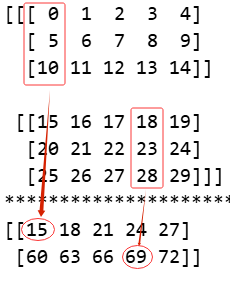

希望读者能理解此方法。

考虑到大型数组难免有缺失值，以上聚合函数碰到缺失值时会报错，因此出现了聚合函数的安全版本，即计算时忽略缺失值：`np.nansum()`、`np.nanprod()` 、`np.nanmean()`、`np.nanstd()`、`np.nanmax()`、`np.nanmin()`。

## 布尔数组

### 创建布尔数组

由于NumPy的主要数据类型是整数型数组或浮点型数组，因此布尔型数组的产生离不开：大于`>`、大于等于`>=`、等于`=`、不等号`!=`、小于`<`、小于等于`<=`。首先，我们将数组与系数作比较，以产生布尔型数组，示例如下。

In [151]:
arr = np.arange(1, 7).reshape((2, 3))
print(arr)
# 与一个常数相比
print(arr >= 4)

# 与一个同尺寸数组相比
arr_ud = np.flipud(arr)
print(arr_ud)
print(arr > arr_ud)


[[1 2 3]
 [4 5 6]]
[[False False False]
 [ True  True  True]]
[[4 5 6]
 [1 2 3]]
[[False False False]
 [ True  True  True]]


最后，还可以同时比较多个条件。Python基础里，同时检查多个条件使用的与、或、非是`and`、`or`、`not`。但NumPy中使用的与、或、非是`&`、`|`、`~`

In [153]:
arr = np.arange(1, 10)
print(arr)

print((arr<4)|(arr>6))

[1 2 3 4 5 6 7 8 9]
[ True  True  True False False False  True  True  True]


### 布尔型数组中True的数量

有三个关于Ture数量的有用函数，分别是`np.sum()`、`np.any()`、`np.all()`。

1. **np.sum()** 函数：统计布尔数组中True的数量：

In [154]:
arr = np.random.randn(10000)

num = np.sum(np.abs(arr) < 1)
print(num)

6818


这里的`np.abs(arr) < 1`可以替换成`(arr < 1)&(arr > -1)` 。此外，最终统计的数量是6818，其接近于概率0.6827，这符合正态分布的规律。

2. **np.any()** 函数：只要布尔型数组中有一个即以上的True，就返回True


In [164]:
arr1 = np.arange(1, 10)
arr2 = np.flipud(arr1)
print(arr1)
print(arr2)
print(np.any(arr1==arr2))

[1 2 3 4 5 6 7 8 9]
[9 8 7 6 5 4 3 2 1]
True


从结果中看出，两个数组有相同的元素5，故会输出True

3. **np.all()** 函数：当布尔型数组里全是True时，才会返回True。

In [166]:
arr = np.random.normal(500, 70, 100000)

print(np.all(arr > 250))

False


### 布尔型数组作为掩码

若一个普通数组和一个布尔型数组的维度相同，可以将布尔型数组作为普通数组的掩码，这样可以对普通数组中的元素作筛选。给出两个示例。

第一个示例，筛选出数组中大于、等于或小于某个数字的元素。

In [167]:
arr = np.arange(1, 13).reshape((3, 4))
print(arr > 4)
print(arr[arr > 4])

[[False False False False]
 [ True  True  True  True]
 [ True  True  True  True]]
[ 5  6  7  8  9 10 11 12]


注意，这个矩阵进行掩码操作以后，会退化回向量。

第二个实例，筛选出数组逐元素比较的结果。

In [168]:
arr1 = np.arange(1, 10)
arr2 = np.flipud(arr1)

print(arr1 > arr2)

print(arr1[arr1 > arr2])
print(arr2[arr1 > arr2])

[False False False False False  True  True  True  True]
[6 7 8 9]
[4 3 2 1]


### 满足条件的元素所在位置

现在我们来思考一种情况：假设一个很长的数组，我想知道满足某个条件的元素们所在的索引位置，此时使用`np.where()`函数。

In [172]:
arr = np.random.normal(500, 70, 1000)

print(np.where(arr > 650))
print(np.where(arr == np.max(arr)), np.max(arr))

(array([ 98, 124, 161, 427, 639, 747, 845, 925, 996], dtype=int64),)
(array([124], dtype=int64),) 737.3327010075612


`np.where()`函数的输出看起来比较怪异，它是输出了一个元组。元组第一个元素是**满足条件的元素所在位置**第二个元素是**数组类型**

## 从数组到张量

### 数组与张量

1. PyTorch作为当前首屈一指的深度学习库，其将NumPy的语法尽数吸收，作为自己处理数组的基本语法，且运算速度从使用CPU的数组进步到使用GPU的张量。

2. NumPy和PyTorch的基础语法几乎一致，具体表现为：

- np 对应 torch；
- 数组array对应张量tensor;
- NumPy的n维数组对应着PyTorch的n阶张量。

3. 数组与张量之间可以相互转换：

- 数组arr转为张量ts:`ts = torch.tensor(arr)`;
- 张量 ts转为数组arr:`arr = np.array(ts)`。

### 不同点

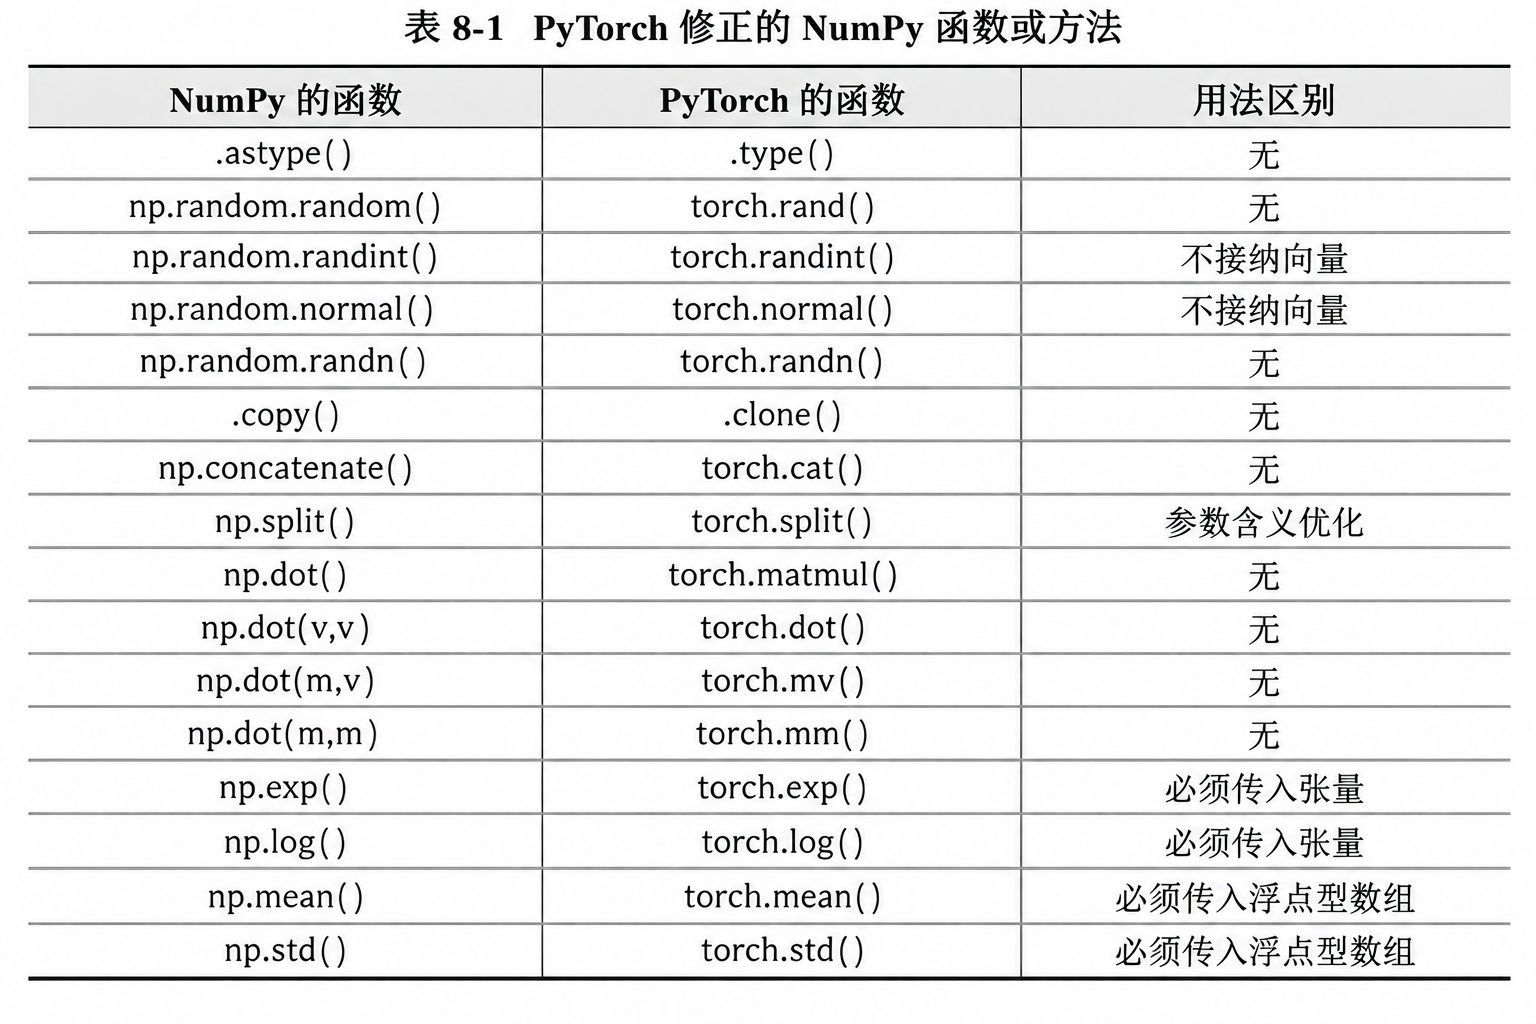

如果还想更细节的了解NumPy库，可以前往<a href="https://www.runoob.com/numpy/numpy-tutorial.html" target="_blank">NumPy详细教程</a>